# p80 control — `filt2` vs `filt2 + ω_k=1/m_b` (global EM)

Homogeneous **80-cactus-founder** panel (no PanGenie short-read founders), so there is **no cactus-vs-PG class imbalance** for 1/m_b to correct. If 1/m_b were a principled de-replication weight it should be ~neutral here.

**Result: it is not neutral — plain `filt2` (uniform) beats `filt2+1/m_b` in every regime, metric, and variant class.** The penalty is largest in clean/low-recomb regimes (g0: +27–41% MAE) and shrinks at high recomb (g3: +2%), where the global-h approximation error dominates.

Interpretation: 1/m_b down-weights large-bubble k-mers, which carry real per-founder *discrimination* (not redundancy). Its win on the heterogeneous 231-panel was coincidental cancellation of cactus over-credit, not an intrinsic gain.

Source: `results/filt2_mb_vs_uniform_summary.tsv` (built by `scripts/score_filt2_mb_vs_uniform.py`); est TSVs from `07c_run_kmate_filt2_mb_p80.sh` (global mode, chr1, seed 42, single replicate).

In [1]:
import os, math
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
CTRL="/global/scratch/users/tbellg/kmate/benchmarks/p80"
df=pd.read_csv(f"{CTRL}/results/filt2_mb_vs_uniform_summary.tsv", sep="\t")
REGIMES=["n50_g0","n80_g0","n50_g1","n80_g1","n50_g3","n50_g3_dom500"]
df["regime"]=pd.Categorical(df.regime, categories=REGIMES, ordered=True)
allc=df[df.cls=="ALL"].pivot(index="regime", columns="weight", values=["MAE","RMSE","outlier","R2","bias"])
allc.columns=[f"{m}_{w}" for m,w in allc.columns]
allc["MAE_pct_worse"]=(100*(allc.MAE_inv_mb-allc.MAE_uniform)/allc.MAE_uniform).round(1)
pd.set_option("display.width",200,"display.max_columns",30)
print("ALL-class, uniform vs inv_mb (1/m_b):"); allc.round(5)

ALL-class, uniform vs inv_mb (1/m_b):


,MAE_inv_mb,MAE_uniform,RMSE_inv_mb,RMSE_uniform,outlier_inv_mb,outlier_uniform,R2_inv_mb,R2_uniform,bias_inv_mb,bias_uniform,MAE_pct_worse
regime,,,,,,,,,,,
n50_g0,0.01092,0.00836,0.01776,0.01374,0.00133,0.00049,0.99209,0.99527,-0.00238,-0.00166,30.5
n80_g0,0.01023,0.00803,0.01643,0.01306,0.00140,0.00113,0.99311,0.99565,-0.00229,-0.00163,27.4
n50_g1,0.01417,0.01276,0.02378,0.02170,0.00386,0.00237,0.98703,0.98920,-0.00184,-0.00120,11.1
n80_g1,0.01380,0.01218,0.02835,0.02608,0.00299,0.00222,0.97995,0.98304,-0.00161,-0.00102,13.3
n50_g3,0.02785,0.02717,0.05168,0.05048,0.06364,0.06103,0.94257,0.94521,-0.00245,-0.00195,2.5
n50_g3_dom500,0.05029,0.04923,0.09529,0.09350,0.18031,0.17695,0.80477,0.81202,-0.00552,-0.00524,2.1


## MAE / RMSE / outlier-rate by regime
Grouped bars: blue = `filt2` (uniform), orange = `filt2+1/m_b`. Uniform (blue) is lower=better on all three, every regime.

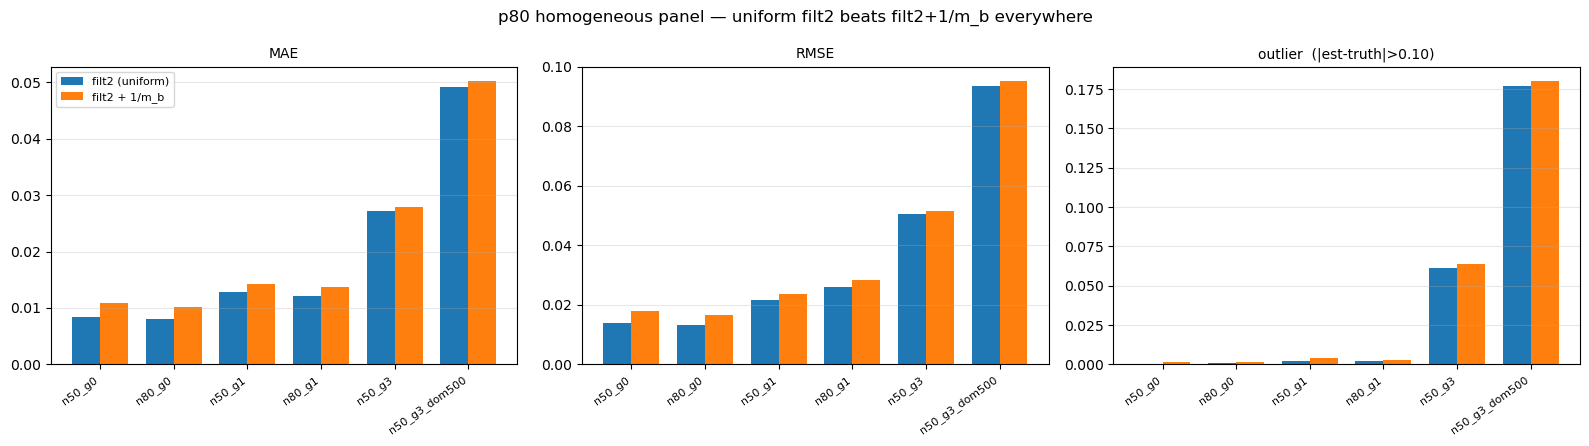

In [2]:
metrics=[("MAE","MAE"),("RMSE","RMSE"),("outlier","outlier  (|est-truth|>0.10)")]
fig,axes=plt.subplots(1,3,figsize=(16,4.5))
x=np.arange(len(REGIMES)); w=0.38
for ax,(key,title) in zip(axes,metrics):
    u=df[(df.cls=='ALL')&(df.weight=='uniform')].set_index('regime').loc[REGIMES,key].values
    m=df[(df.cls=='ALL')&(df.weight=='inv_mb')].set_index('regime').loc[REGIMES,key].values
    ax.bar(x-w/2,u,w,label='filt2 (uniform)',color='#1f77b4')
    ax.bar(x+w/2,m,w,label='filt2 + 1/m_b',color='#ff7f0e')
    ax.set_xticks(x); ax.set_xticklabels(REGIMES,rotation=35,ha='right',fontsize=8)
    ax.set_title(title,fontsize=10); ax.grid(axis='y',alpha=.3)
    if key=='MAE': ax.legend(fontsize=8)
fig.suptitle("p80 homogeneous panel — uniform filt2 beats filt2+1/m_b everywhere",fontsize=12)
fig.tight_layout()
fig.savefig(f"{CTRL}/results/plots/filt2_mb_vs_uniform_bars.png",dpi=120,bbox_inches='tight')
plt.show()

## 1/m_b penalty by regime
Percent increase in MAE from adding 1/m_b (positive = worse). Worst in clean g0, negligible at high-recomb g3 (where global-h approximation error swamps the weighting).

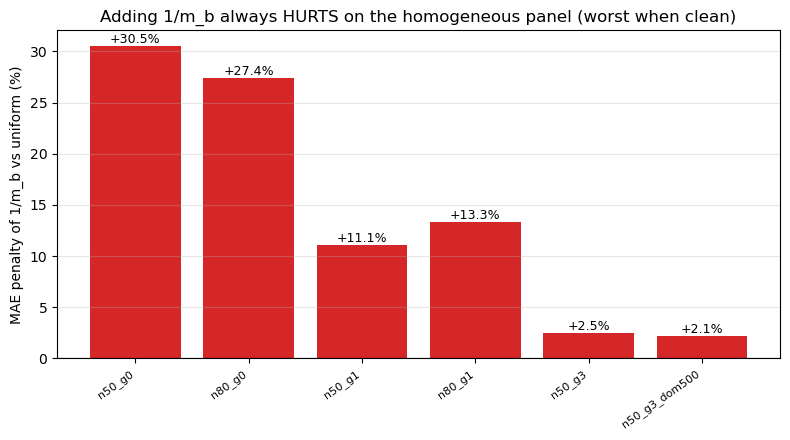

In [3]:
u=df[(df.cls=='ALL')&(df.weight=='uniform')].set_index('regime').loc[REGIMES,'MAE'].values
m=df[(df.cls=='ALL')&(df.weight=='inv_mb')].set_index('regime').loc[REGIMES,'MAE'].values
pen=100*(m-u)/u
fig,ax=plt.subplots(figsize=(8,4.5))
bars=ax.bar(REGIMES,pen,color=['#d62728' if p>0 else '#2ca02c' for p in pen])
for b,p in zip(bars,pen): ax.annotate(f"+{p:.1f}%",(b.get_x()+b.get_width()/2,p),ha='center',va='bottom',fontsize=9)
ax.axhline(0,color='k',lw=.8); ax.set_ylabel("MAE penalty of 1/m_b vs uniform (%)")
ax.set_xticks(range(len(REGIMES))); ax.set_xticklabels(REGIMES,rotation=35,ha='right',fontsize=8)
ax.set_title("Adding 1/m_b always HURTS on the homogeneous panel (worst when clean)")
ax.grid(axis='y',alpha=.3); fig.tight_layout()
fig.savefig(f"{CTRL}/results/plots/filt2_mb_penalty.png",dpi=120,bbox_inches='tight')
plt.show()

## True vs estimated AF — cleanest (n50_g0) and hardest (n50_g3)
Hexbin, log color. Both weights hug the diagonal; uniform (left) is visibly tighter. Join on (chrom,pos,ref_len,alt_len).

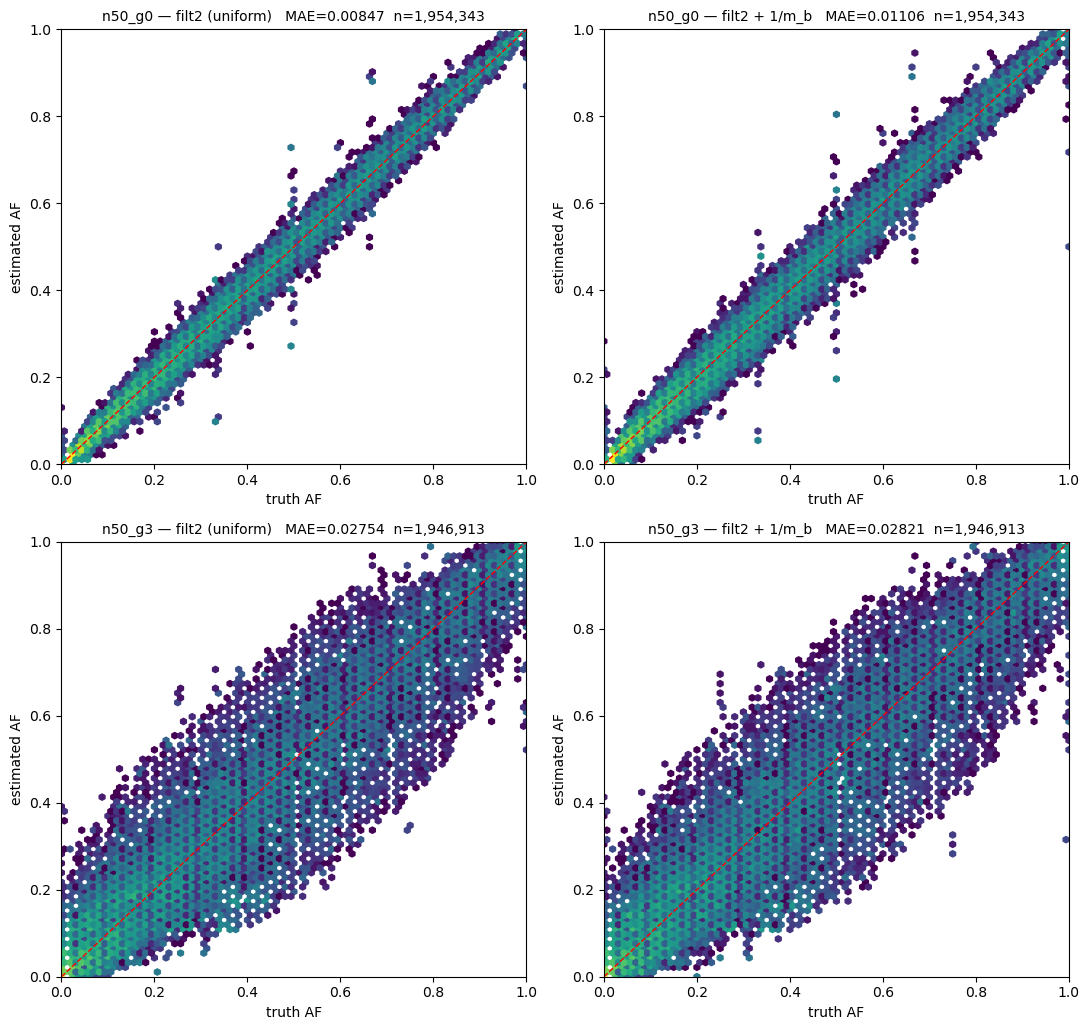

In [4]:
KEYS=["chrom","pos","ref_len","alt_len"]
def truth_path(reg):
    n=reg.split("_g")[0][1:]; g=reg.split("_g")[1].replace("_dom500","")
    sub="hotspots_dom500_p80_chr1" if "dom500" in reg else "hotspots_p80_chr1"
    return f"{CTRL}/sims/cov10_n{n}_g{g}_s42_{sub}/recomb_truth.tsv.gz"
def est_path(reg,w):
    od="cactus_em_global_filt2_mb" if w=="inv_mb" else "cactus_em_global_filt2_uniform"
    wt="filt2mb" if w=="inv_mb" else "filt2u"
    return f"{CTRL}/results/{od}/{reg}/p80_{wt}_{reg}_cov10_s42.tsv"
show=["n50_g0","n50_g3"]; weights=[("uniform","filt2 (uniform)"),("inv_mb","filt2 + 1/m_b")]
fig,ax=plt.subplots(len(show),2,figsize=(11,5.2*len(show)))
for ri,reg in enumerate(show):
    tr=pd.read_csv(truth_path(reg),sep="\t").dropna(subset=["truth_af"]).drop_duplicates(KEYS)
    for ci,(w,lab) in enumerate(weights):
        es=pd.read_csv(est_path(reg,w),sep="\t").drop_duplicates(KEYS)
        mg=tr.merge(es[KEYS+["alt_freq"]],on=KEYS,how="inner")
        xx=mg.truth_af.values.astype(float); yy=mg.alt_freq.values.astype(float)
        mae=np.abs(xx-yy).mean(); a=ax[ri,ci]
        a.hexbin(xx,yy,gridsize=80,bins="log",cmap="viridis",mincnt=1); a.plot([0,1],[0,1],"r--",lw=1)
        a.set_xlim(0,1); a.set_ylim(0,1); a.set_xlabel("truth AF"); a.set_ylabel("estimated AF")
        a.set_title(f"{reg} — {lab}   MAE={mae:.5f}  n={len(mg):,}",fontsize=10)
fig.tight_layout()
fig.savefig(f"{CTRL}/results/plots/filt2_mb_vs_uniform_scatter.png",dpi=110,bbox_inches='tight')
plt.show()

## 6-regime × 2-method density panels (FINAL_RESULTS style)
Uniform `filt2` vs `filt2 + ω=1/m_b` (global EM), 6 regimes × 2 methods, density-colored log scatter. Row-aligned record-index join (NOT 4-key — multiallelic-safe). Mirrors `FINAL_RESULTS_cov10_p80.ipynb` cells 10/11.

In [5]:
import sys as _sys
_sys.path.insert(0, "/global/scratch/users/tbellg/kmate/benchmarks")
from _accuracy_panel import scatter_density  # canonical shared aesthetic

import numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from pathlib import Path
ROOT=Path("/global/scratch/users/tbellg/kmate/benchmarks/p80")
RES=ROOT/"results"; SIMS=ROOT/"sims"; PLOTS=RES/"plots"; PLOTS.mkdir(parents=True,exist_ok=True)
GREY="#888888"
REGIMES=["n80_g0","n50_g0","n80_g1","n50_g1","n50_g3","n50_g3_dom500"]
METHODS=["uniform","inv_mb"]
METHOD_LABELS={"uniform":"filt2 (uniform)","inv_mb":"filt2 + 1/m_b"}
SUBDIR={r:("cov10_n50_g3_s42_hotspots_dom500_p80_chr1" if r=="n50_g3_dom500"
           else f"cov10_{r.split('_g')[0]}_g{r.split('_g')[1]}_s42_hotspots_p80_chr1") for r in REGIMES}
def est_path(reg,w):
    od="cactus_em_global_filt2_mb" if w=="inv_mb" else "cactus_em_global_filt2_uniform"
    wt="filt2mb" if w=="inv_mb" else "filt2u"
    return RES/od/reg/f"p80_{wt}_{reg}_cov10_s42.tsv"
# Build big df: record-index join est<->truth per (regime, method). p80 F=80.
F=80
rows=[]
for reg in REGIMES:
    tp=SIMS/SUBDIR[reg]/"recomb_truth.tsv.gz"
    tr=pd.read_csv(tp,sep="\t")
    for w in METHODS:
        ep=est_path(reg,w); 
        if not ep.exists(): print(f"missing {ep}"); continue
        es=pd.read_csv(ep,sep="\t")
        assert len(es)==len(tr)
        miss=(F-es["n_called"].values)/F
        sub=pd.DataFrame({"regime":reg,"method":w,
                          "truth":tr["truth_af"].values,"est":es["alt_freq"].values,
                          "missing_frac":miss})
        rows.append(sub)
big=pd.concat(rows,ignore_index=True)
print("big df:",big.shape," NaN truth:",big["truth"].isna().sum())

def regime_method_panel(df,regimes,methods,suptitle,filename):
    CELL=4.0
    fig,axes=plt.subplots(len(regimes),len(methods),
                          figsize=(CELL*len(methods)+1,CELL*len(regimes)+0.5),
                          sharex=True,sharey=True)
    last_sm=None
    for i,reg in enumerate(regimes):
        for j,m in enumerate(methods):
            ax=axes[i,j] if len(regimes)>1 else axes[j]
            sub=df[(df.regime==reg)&(df.method==m)]
            sm=scatter_density(ax,sub["truth"].to_numpy(),sub["est"].to_numpy(),
                               title=f"{METHOD_LABELS[m]}  ·  {reg}")
            if sm is not None: last_sm=sm
            if j==0: ax.set_ylabel("Estimated AF")
            if i==len(regimes)-1: ax.set_xlabel("True AF")
    fig.subplots_adjust(bottom=0.06,top=0.96,hspace=0.30,wspace=0.10)
    cax=fig.add_axes([0.25,0.025,0.50,0.008])
    if last_sm is not None:
        cb=fig.colorbar(last_sm,cax=cax,orientation="horizontal",label="Local density (log count of records)")
        cb.outline.set_edgecolor(GREY); cb.ax.xaxis.set_tick_params(color=GREY,labelcolor=GREY); cb.ax.xaxis.label.set_color(GREY)
    fig.suptitle(suptitle,y=0.985,fontsize=11,color=GREY)
    plt.savefig(PLOTS/filename,dpi=130,bbox_inches="tight"); plt.show(); print(f"saved: plots/{filename}")


big df: (24586104, 5)  NaN truth: 46984


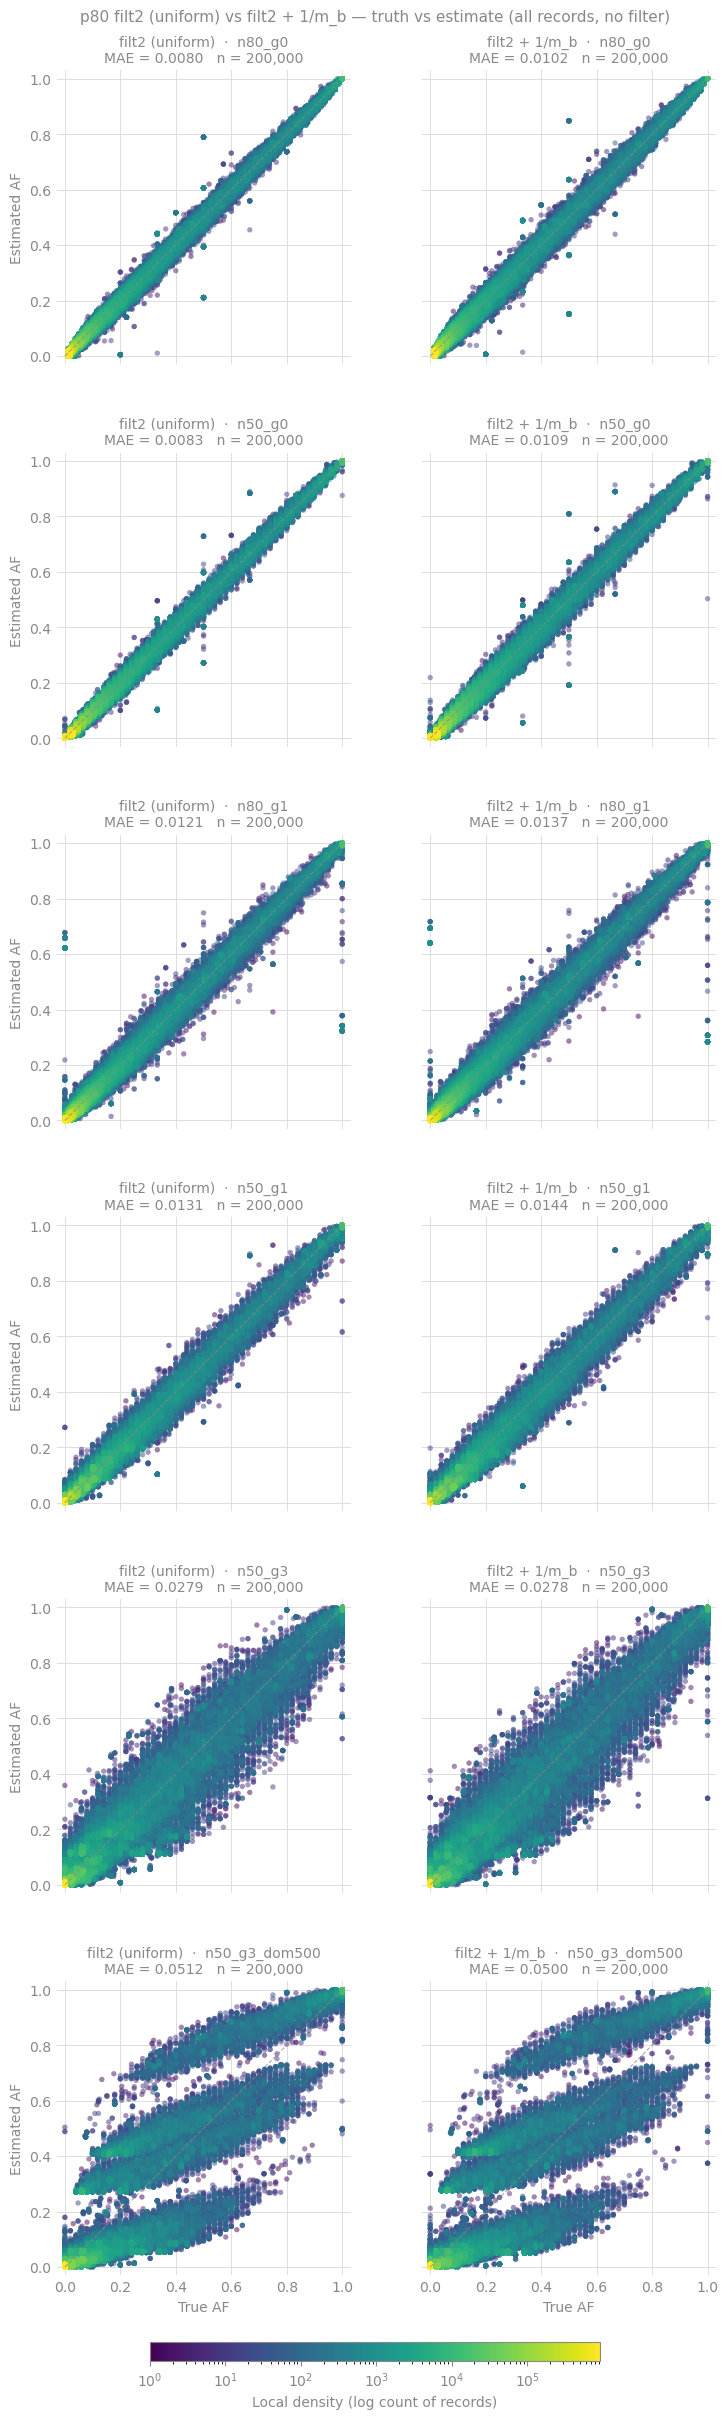

saved: plots/panel_filt2mb_no_filter.png


In [6]:
# Panel 1 of 2: NO missingness filter, all records, 6 regimes x 2 methods.
regime_method_panel(big, REGIMES, METHODS,
    suptitle="p80 filt2 (uniform) vs filt2 + 1/m_b — truth vs estimate (all records, no filter)",
    filename="panel_filt2mb_no_filter.png")

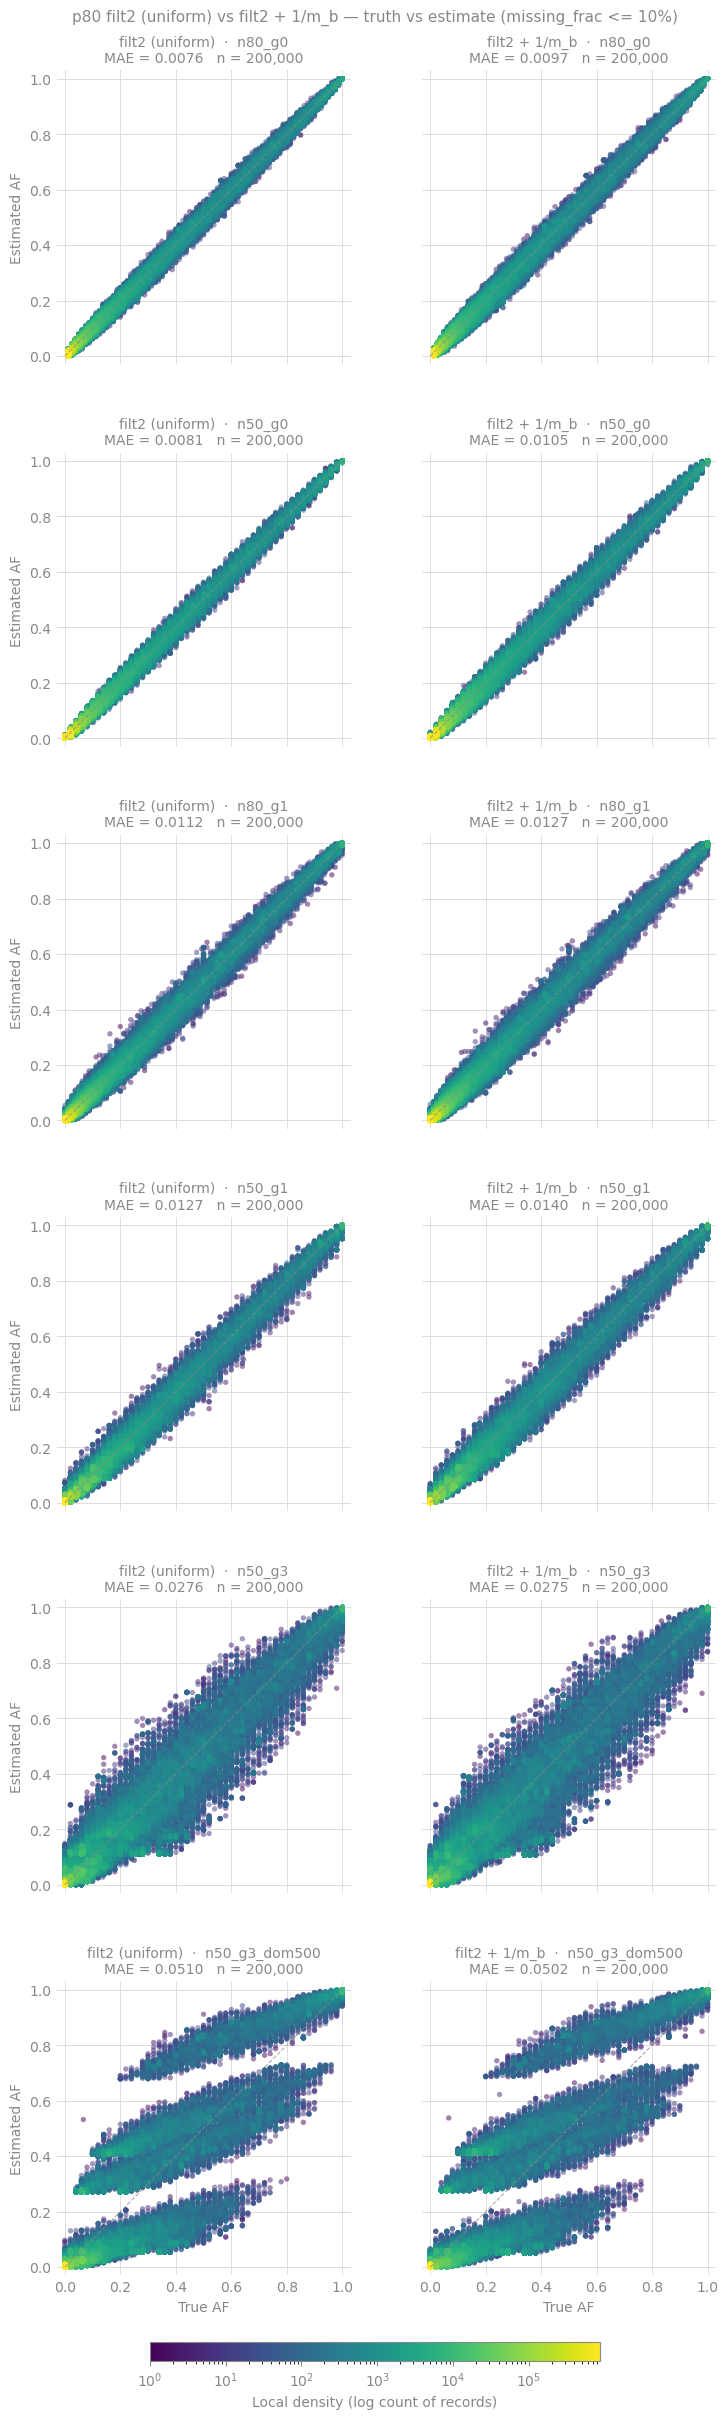

saved: plots/panel_filt2mb_miss10.png


In [7]:
# Panel 2 of 2: missingness filter (missing_frac <= 10%). Same layout.
regime_method_panel(big[big["missing_frac"]<=0.10], REGIMES, METHODS,
    suptitle="p80 filt2 (uniform) vs filt2 + 1/m_b — truth vs estimate (missing_frac <= 10%)",
    filename="panel_filt2mb_miss10.png")

## filt2 + 1/m_b — chromosome (global) vs window (10 kb / star2)

Side-by-side mirror of `FINAL_RESULTS_cov10_p80.ipynb` cells 10/11 (which shows filt2-uniform × the same two modes). Same 6 regimes, same layout — line these two figures up to read 1/m_b's effect at each (regime, mode).
Window-mode EM uses ω_k=1/m_b applied per block (`solve_em_per_block(omega=)`), --window-bp 10000 --anchor 0.3 --smooth 5α0.5. Record-index join (multiallelic-safe).

In [8]:
import sys as _sys
_sys.path.insert(0, "/global/scratch/users/tbellg/kmate/benchmarks")
from _accuracy_panel import scatter_density  # canonical shared aesthetic

import numpy as np, pandas as pd, matplotlib, matplotlib.pyplot as plt, gc
from matplotlib.colors import LogNorm
from pathlib import Path
ROOT=Path("/global/scratch/users/tbellg/kmate/benchmarks/p80")
RES=ROOT/"results"; SIMS=ROOT/"sims"; PLOTS=RES/"plots"; PLOTS.mkdir(parents=True,exist_ok=True)
GREY="#888888"; F=80
REGIMES=["n80_g0","n50_g0","n80_g1","n50_g1","n50_g3","n50_g3_dom500"]
MODES=["global","window"]
MODE_LABELS={"global":"h chromosome (filt2 + 1/m_b)","window":"h 10kb window (filt2 + 1/m_b)"}
def subdir(reg):
    if reg=="n50_g3_dom500": return "cov10_n50_g3_s42_hotspots_dom500_p80_chr1"
    n,g=reg.split("_g"); return f"cov10_{n}_g{g}_s42_hotspots_p80_chr1"
def est_path(reg,mode):
    if mode=="global":
        return RES/"cactus_em_global_filt2_mb"/reg/f"p80_filt2mb_{reg}_cov10_s42.tsv"
    return RES/"cactus_em_window_filt2_mb"/reg/f"p80_filt2mbW_{reg}_cov10_s42.tsv"

def load_cell(reg,mode):
    tp=SIMS/subdir(reg)/"recomb_truth.tsv.gz"
    ep=est_path(reg,mode)
    tr=pd.read_csv(tp,sep="\t",usecols=["truth_af"])
    es=pd.read_csv(ep,sep="\t",usecols=["alt_freq","n_called"])
    assert len(tr)==len(es), f"len mismatch {reg} {mode}"
    return tr["truth_af"].values.astype(np.float32), es["alt_freq"].values.astype(np.float32), ((F-es["n_called"].values)/F).astype(np.float32)

def regime_mode_panel(miss_thr,suptitle,filename):
    CELL=4.0
    fig,axes=plt.subplots(len(REGIMES),len(MODES),figsize=(CELL*len(MODES)+1,CELL*len(REGIMES)+0.5),sharex=True,sharey=True)
    last_sm=None
    for i,reg in enumerate(REGIMES):
        for j,mode in enumerate(MODES):
            ax=axes[i,j] if len(REGIMES)>1 else axes[j]
            truth,est,miss=load_cell(reg,mode)
            sel=miss<=miss_thr
            sm=scatter_density(ax,truth[sel],est[sel],title=f"{MODE_LABELS[mode]}  ·  {reg}")
            if sm is not None: last_sm=sm
            if j==0: ax.set_ylabel("Estimated AF")
            if i==len(REGIMES)-1: ax.set_xlabel("True AF")
            del truth,est,miss; gc.collect()
    fig.subplots_adjust(bottom=0.06,top=0.96,hspace=0.30,wspace=0.10)
    cax=fig.add_axes([0.25,0.025,0.50,0.008])
    if last_sm is not None:
        cb=fig.colorbar(last_sm,cax=cax,orientation="horizontal",label="Local density (log count of records)")
        cb.outline.set_edgecolor(GREY); cb.ax.xaxis.set_tick_params(color=GREY,labelcolor=GREY); cb.ax.xaxis.label.set_color(GREY)
    fig.suptitle(suptitle,y=0.985,fontsize=11,color=GREY)
    plt.savefig(PLOTS/filename,dpi=130,bbox_inches="tight"); plt.show(); plt.close(fig); gc.collect()
    print(f"saved: plots/{filename}")
print("helpers ready")

helpers ready


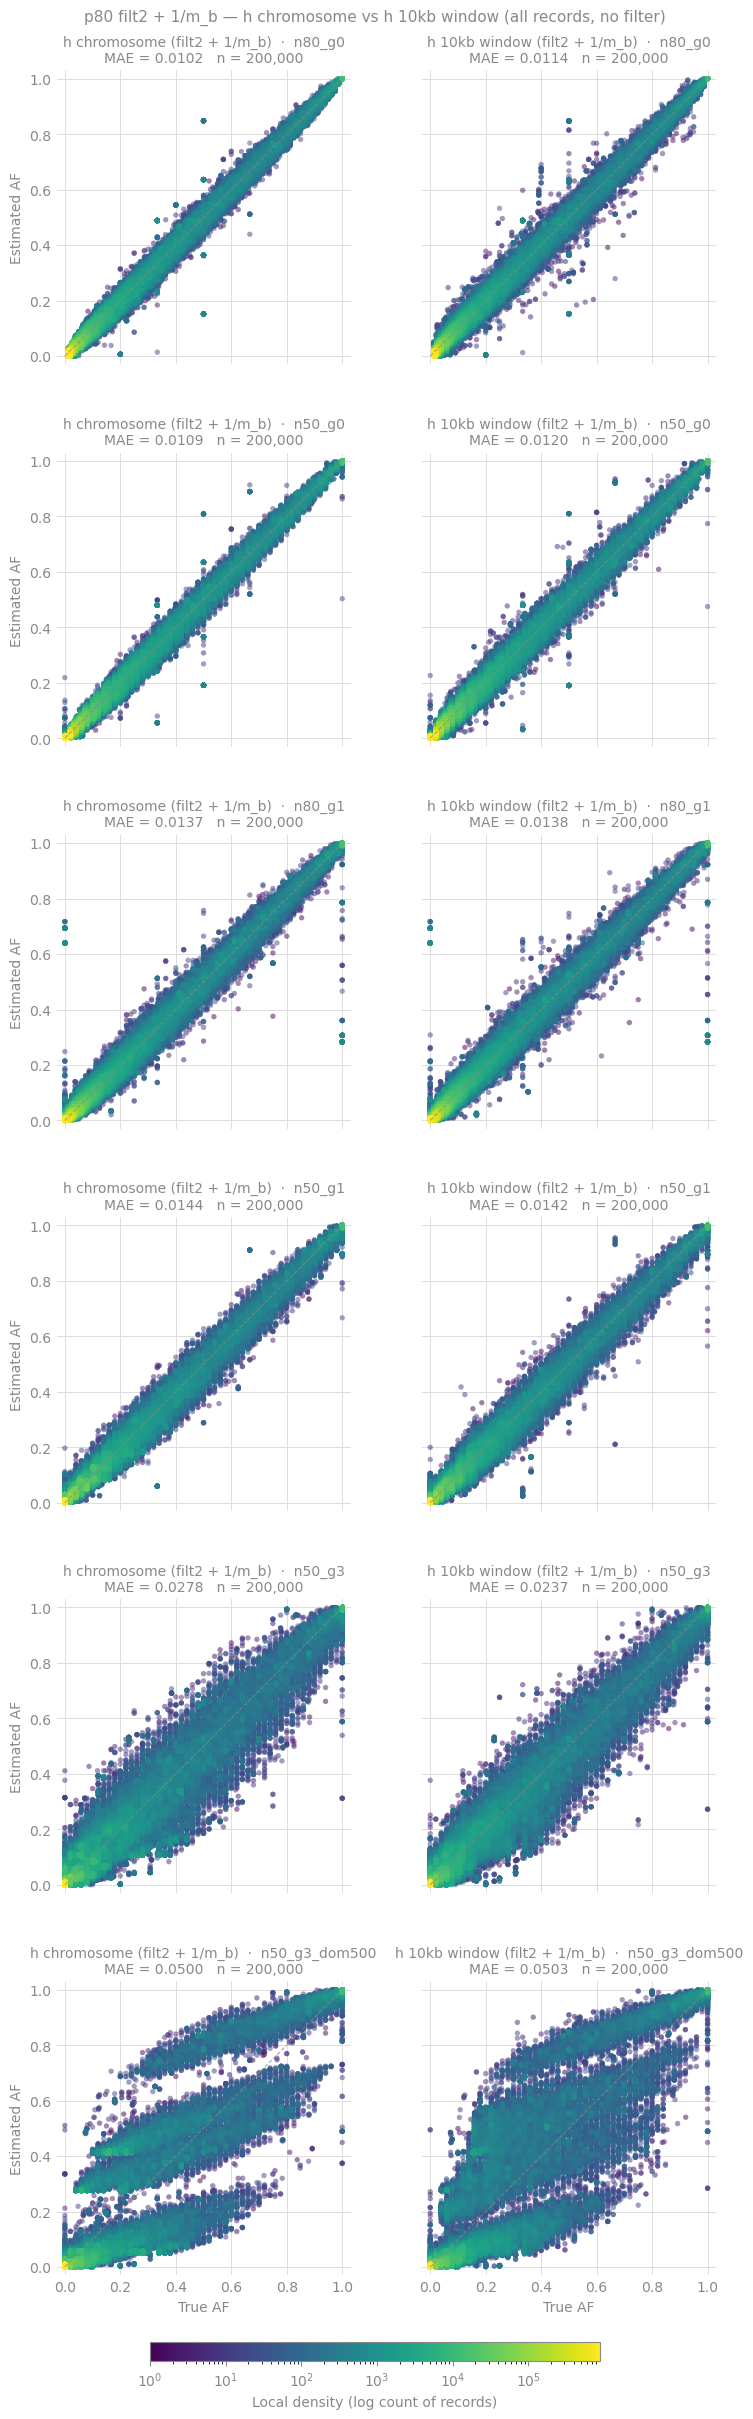

saved: plots/panel_filt2mb_global_vs_window_no_filter.png


In [9]:
# Panel 1 of 2: NO missingness filter. Side-by-side with FINAL_RESULTS_cov10_p80 cell 10.
regime_mode_panel(miss_thr=2.0,
    suptitle="p80 filt2 + 1/m_b — h chromosome vs h 10kb window (all records, no filter)",
    filename="panel_filt2mb_global_vs_window_no_filter.png")

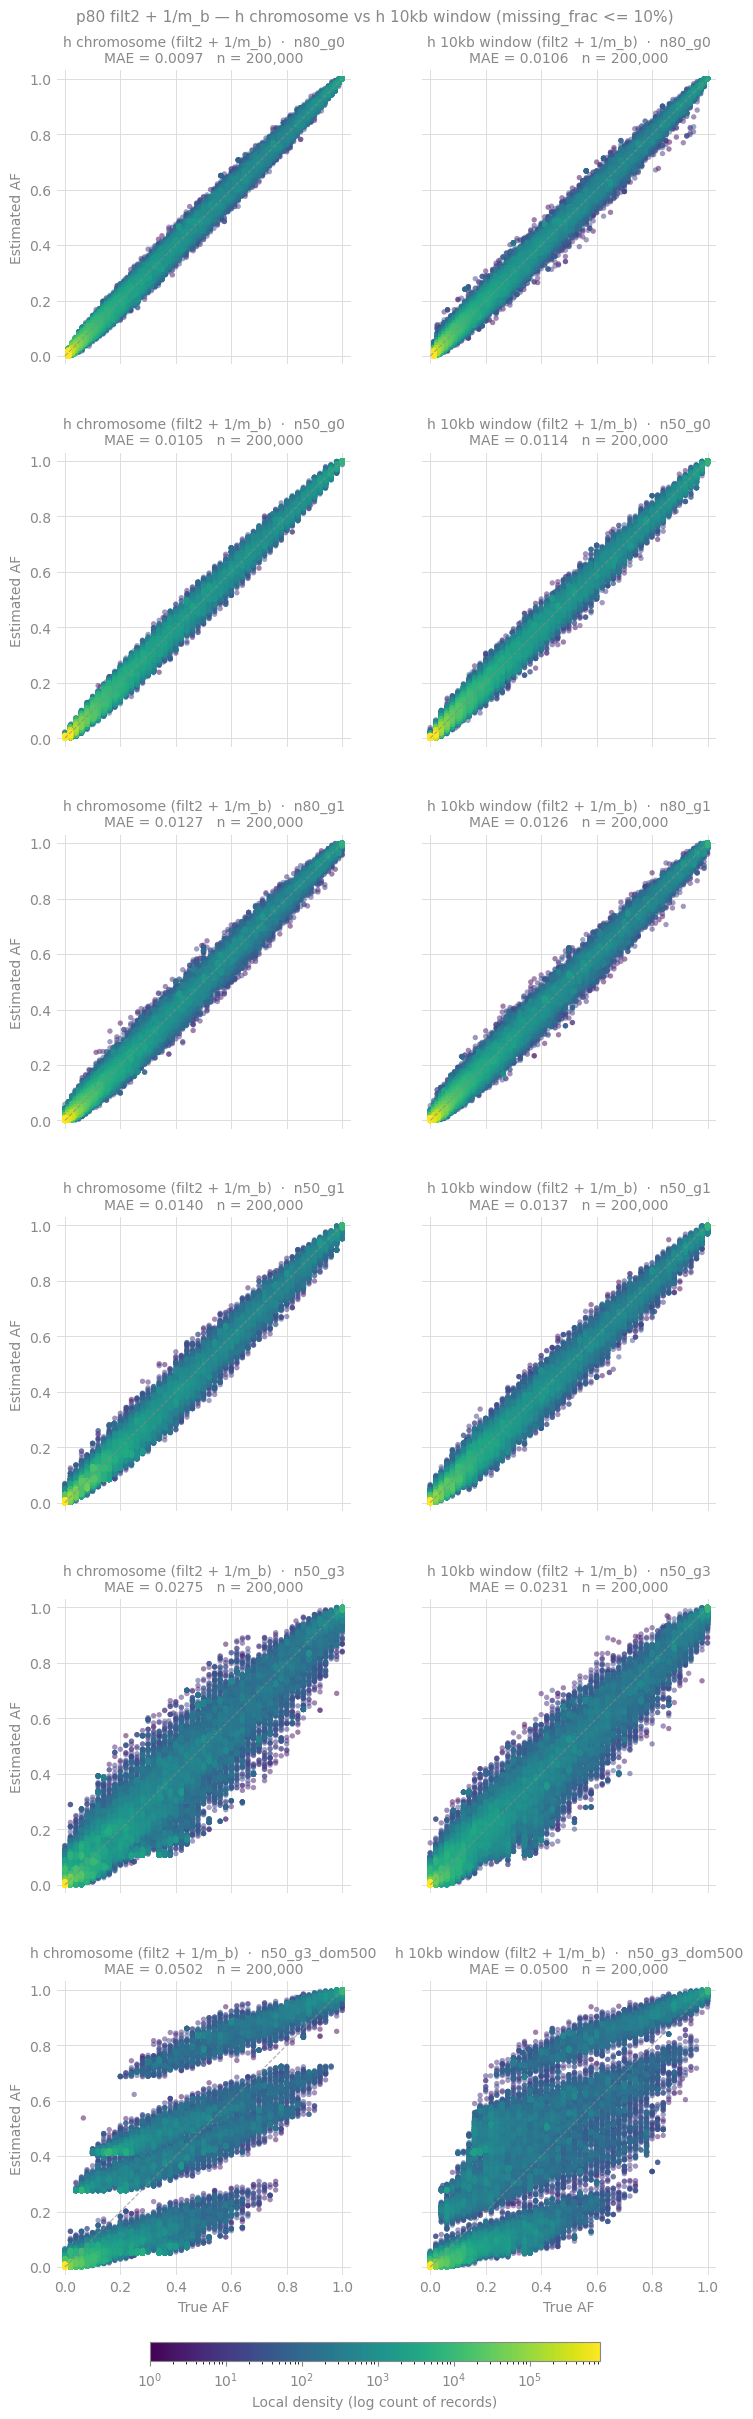

saved: plots/panel_filt2mb_global_vs_window_miss10.png


In [10]:
# Panel 2 of 2: missingness filter (missing_frac <= 10%). Side-by-side with FINAL_RESULTS_cov10_p80 cell 11.
regime_mode_panel(miss_thr=0.10,
    suptitle="p80 filt2 + 1/m_b — h chromosome vs h 10kb window (missing_frac <= 10%)",
    filename="panel_filt2mb_global_vs_window_miss10.png")